# Project 6 — Frequency-Domain Diffusion Models for Deepfake Analysis

## 1. Imports

In [ ]:
import math
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.amp import autocast, GradScaler

from torchvision import transforms
from torchvision.utils import make_grid, save_image

from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

## 2. Globals

In [ ]:
SEED = 42

# --- Paths -------------------------------------------------------------
KAGGLE_DATASET_NAME="greatgamedota/ffhq-face-data-set"
DATA_DIR = Path("./ffhq128")
CKPT_DIR = Path("./checkpoints")
SAMPLE_DIR = Path("./samples")
for d in (CKPT_DIR, SAMPLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

# --- Device to run on --------------------------------------------------
DEVICE = "cpu"
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
DEVICE = torch.device(DEVICE)

# --- Data --------------------------------------------------------------
IMG_SIZE = 128
IMG_CHANNELS = 3
MAX_VAL_SIZE = 10000
BATCH_SIZE = 32
NUM_WORKERS = 0

FREQ_MEAN = None # Assigned when run compute_freq_stats()
FREQ_STD = None

# --- DDPM --------------------------------------------------------------
TIMESTEPS = 1000
BETA_START = 1e-4
BETA_END = 0.02

DDIM_STEPS = 50
DDIM_ETA = 0.0

# --- Training ----------------------------------------------------------
LR = 2e-4
EPOCHS = 100
LOG_EVERY = 100
SAMPLE_EVERY_EPOCHS = 5


DOMAIN = "fft" # Choose between "rgb" and "fft" to train the model on the corresponding domain


def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)


set_seed()
print(f"Device: {DEVICE} | domain: {DOMAIN} | image size: {IMG_SIZE}")

## 3. Utils

In [41]:
# ---------------------------------------------------------------------------
# 3.1 Forward and Inverse FFT
# ---------------------------------------------------------------------------

def to_freq(img: torch.Tensor) -> torch.Tensor:
    f = torch.fft.fft2(img, norm="ortho")
    f = torch.fft.fftshift(f, dim=(-2, -1))
    return torch.cat([f.real, f.imag], dim=1)


def from_freq(freq: torch.Tensor) -> torch.Tensor:
    c = freq.shape[1] // 2
    real, imag = freq[:, :c], freq[:, c:]
    f = torch.complex(real, imag)
    f = torch.fft.ifftshift(f, dim=(-2, -1))
    img = torch.fft.ifft2(f, norm="ortho").real
    return img


# ---------------------------------------------------------------------------
# 3.2 Spectral normalization
# ---------------------------------------------------------------------------

# Step 1: Logarithmic compression (log1p) and decompression (expm1)
def compress(x: torch.Tensor) -> torch.Tensor:
    return torch.sign(x) * torch.log1p(x.abs())


def decompress(x: torch.Tensor) -> torch.Tensor:
    return torch.sign(x) * torch.expm1(x.abs())


# Step 2: Channel standardization (mean/std normalization) in the frequency domain
def normalize_freq(freq: torch.Tensor) -> torch.Tensor:
    x = compress(freq)
    return (x - FREQ_MEAN.to(x.device)) / FREQ_STD.to(x.device)


def denormalize_freq(x: torch.Tensor) -> torch.Tensor:
    x = x * FREQ_STD.to(x.device) + FREQ_MEAN.to(x.device)
    return decompress(x)


@torch.no_grad()
def compute_freq_stats(loader, n_batches: int = 30):
    sums = None
    sq_sums = None
    n_pixels = 0
    count = 0
    for batch in loader:
        img = batch.to(DEVICE)
        freq = compress(to_freq(img))
        if sums is None:
            sums = freq.sum(dim=(0, 2, 3))
            sq_sums = (freq ** 2).sum(dim=(0, 2, 3))
        else:
            sums += freq.sum(dim=(0, 2, 3))
            sq_sums += (freq ** 2).sum(dim=(0, 2, 3))
        n_pixels += img.shape[0] * img.shape[2] * img.shape[3]
        count += 1
        if count >= n_batches:
            break
    mean = sums / n_pixels
    var = sq_sums / n_pixels - mean ** 2
    std = var.clamp(min=1e-8).sqrt()
    return mean.view(-1, 1, 1).cpu(), std.view(-1, 1, 1).cpu()


# ---------------------------------------------------------------------------
# 3.3 Sanity check for FFT roundtrip
# ---------------------------------------------------------------------------
def fft_roundtrip_check(img_batch: torch.Tensor, tol: float = 1e-4):
    freq = to_freq(img_batch)
    recon = from_freq(freq)
    err = (img_batch - recon).abs().max().item()
    status = "OK" if err < tol else "ATTENZIONE: errore alto"
    print(f"[FFT roundtrip check] absolute maximum error: {err:.2e}  -> {status}")
    return err


# ---------------------------------------------------------------------------
# 3.4 Radial power spectrum and plotting
# ---------------------------------------------------------------------------
@torch.no_grad()
def radial_power_spectrum(img_batch: torch.Tensor, n_bins: int = 64) -> np.ndarray:
    b, c, h, w = img_batch.shape
    f = torch.fft.fft2(img_batch, norm="ortho")
    f = torch.fft.fftshift(f, dim=(-2, -1))
    power = (f.real ** 2 + f.imag ** 2).mean(dim=(0, 1))  # (H, W)

    yy, xx = torch.meshgrid(
        torch.arange(h, device=power.device) - h // 2,
        torch.arange(w, device=power.device) - w // 2,
        indexing="ij",
    )
    r = torch.sqrt(xx.float() ** 2 + yy.float() ** 2)
    r_max = r.max()
    bins = torch.linspace(0, r_max, n_bins + 1, device=power.device)

    radial_profile = np.zeros(n_bins)
    power_np = power.cpu().numpy()
    r_np = r.cpu().numpy()
    bins_np = bins.cpu().numpy()
    for i in range(n_bins):
        mask = (r_np >= bins_np[i]) & (r_np < bins_np[i + 1])
        radial_profile[i] = power_np[mask].mean() if mask.any() else 0.0
    return radial_profile


def plot_radial_spectra(spectra: dict, title: str = "Spettro di potenza radiale mediato"):
    """spectra: dict {label: array 1D}. Plotta in scala log-log per confrontare le curve."""
    plt.figure(figsize=(6, 4))
    for label, spec in spectra.items():
        plt.plot(np.arange(len(spec)), spec + 1e-12, label=label)
    plt.yscale("log")
    plt.xlabel("Raggio in frequenza (bin)")
    plt.ylabel("Potenza media (log)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


## 4. Data

The dataset is taken from the original NVIDIA github repository [NVlabs/ffhq-dataset](https://github.com/NVlabs/ffhq-dataset) but ported in kaggle by this repo [greatgamedota/ffhq-face-data-set](https://www.kaggle.com/datasets/greatgamedota/ffhq-face-data-set)

In [ ]:
import kagglehub

# TO RUN: only if the dataset is not downloaded yet
print(f"Downloading {KAGGLE_DATASET_NAME} dataset!")
path = kagglehub.dataset_download(KAGGLE_DATASET_NAME)
print(f"Dataset downloaded at {path}!")
DATA_DIR = path

In [ ]:
class FFHQDataset(Dataset):
    def __init__(self, root: Path, img_size: int = IMG_SIZE):
        self.paths = sorted(
            [p for p in Path(root).rglob("*") if p.suffix.lower() in (".png", ".jpg", ".jpeg")]
        )
        if len(self.paths) == 0:
            raise FileNotFoundError(
                f"Nessuna immagine trovata in {root} — controlla DATA_DIR nella sezione Globals."
            )
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),                      # [0, 1]
            transforms.Normalize([0.5] * 3, [0.5] * 3),  # -> [-1, 1]
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img)


full_dataset = FFHQDataset(DATA_DIR, IMG_SIZE)
print(f"Immagini totali trovate: {len(full_dataset)}")

val_size = min(MAX_VAL_SIZE, len(full_dataset) // 10)
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(SEED)
)
print(f"Train: {len(train_dataset)} | Val/reference (per FID e confronto spettrale): {len(val_dataset)}")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

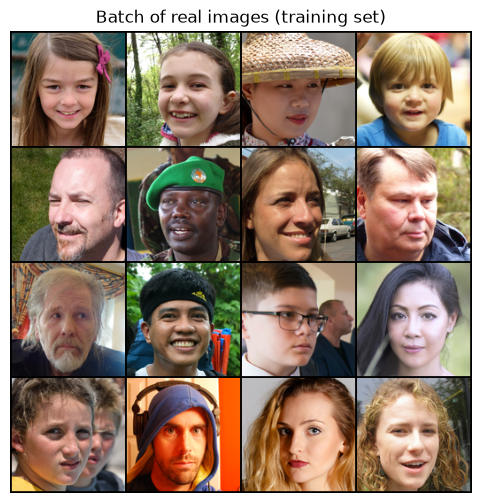

In [44]:
# Visualization of a batch of real images
sample_batch = next(iter(train_loader))
grid = make_grid(sample_batch[:16] * 0.5 + 0.5, nrow=4)
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.axis("off")
plt.title("Batch of real images (training set)")
plt.show()


In [45]:
# Sanity check: FFT forward + inverse
_ = fft_roundtrip_check(sample_batch.to(DEVICE))


[FFT roundtrip check] absolute maximum error: 1.19e-06  -> OK


In [47]:
# Frequency statistics for normalization (only if DOMAIN == 'fft')
if DOMAIN == "fft":
    FREQ_MEAN, FREQ_STD = compute_freq_stats(train_loader, n_batches=30)
    print("FREQ_MEAN shape:", FREQ_MEAN.shape, "| FREQ_STD shape:", FREQ_STD.shape)
    torch.save({"mean": FREQ_MEAN, "std": FREQ_STD}, CKPT_DIR / "freq_stats.pt")


FREQ_MEAN shape: torch.Size([6, 1, 1]) | FREQ_STD shape: torch.Size([6, 1, 1])


## 5. Network

Standard UNet for DDPM (ResBlock + attention at low resolution + sinusoidal time embedding)

In [ ]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
        args = t[:, None].float() * freqs[None, :]
        return torch.cat([args.sin(), args.cos()], dim=-1)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.time_mlp = nn.Linear(time_dim, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_mlp(F.silu(t_emb))[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


class SelfAttention(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.norm = nn.GroupNorm(8, ch)
        self.qkv = nn.Conv2d(ch, ch * 3, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.qkv(self.norm(x)).reshape(b, 3, c, h * w)
        q, k, v = qkv.unbind(1)
        attn = torch.softmax(torch.einsum("bci,bcj->bij", q, k) / math.sqrt(c), dim=-1)
        out = torch.einsum("bij,bcj->bci", attn, v).reshape(b, c, h, w)
        return x + self.proj(out)


class Down(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.op = nn.Conv2d(ch, ch, 3, stride=2, padding=1)

    def forward(self, x):
        return self.op(x)


class Up(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.op = nn.ConvTranspose2d(ch, ch, 4, stride=2, padding=1)

    def forward(self, x):
        return self.op(x)


class UNet(nn.Module):
    """UNet compatta per DDPM. base_ch=64, channel mult (1,2,2,4) -> a 128px arriva a
    risoluzione 16x16 nel bottleneck, dove mettiamo self-attention."""

    def __init__(self, in_channels=3, out_channels=None, base_ch=64,
                 ch_mults=(1, 2, 2, 4), time_dim=256):
        super().__init__()
        out_channels = out_channels or in_channels
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(base_ch),
            nn.Linear(base_ch, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        self.in_conv = nn.Conv2d(in_channels, base_ch, 3, padding=1)

        chans = [base_ch * m for m in ch_mults]
        self.down_blocks = nn.ModuleList()
        self.downs = nn.ModuleList()
        in_ch = base_ch
        for out_ch in chans:
            self.down_blocks.append(ResBlock(in_ch, out_ch, time_dim))
            self.downs.append(Down(out_ch))
            in_ch = out_ch

        self.mid_block1 = ResBlock(in_ch, in_ch, time_dim)
        self.mid_attn = SelfAttention(in_ch)
        self.mid_block2 = ResBlock(in_ch, in_ch, time_dim)

        self.up_blocks = nn.ModuleList()
        self.ups = nn.ModuleList()
        for out_ch in reversed(chans):
            self.ups.append(Up(in_ch))
            self.up_blocks.append(ResBlock(in_ch + out_ch, out_ch, time_dim))
            in_ch = out_ch

        self.out_norm = nn.GroupNorm(8, base_ch)
        self.out_conv = nn.Conv2d(base_ch, out_channels, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        h = self.in_conv(x)
        skips = []
        for block, down in zip(self.down_blocks, self.downs):
            h = block(h, t_emb)
            skips.append(h)
            h = down(h)

        h = self.mid_block1(h, t_emb)
        h = self.mid_attn(h)
        h = self.mid_block2(h, t_emb)

        for up, block in zip(self.ups, self.up_blocks):
            h = up(h)
            skip = skips.pop()
            if h.shape[-2:] != skip.shape[-2:]:
                h = F.interpolate(h, size=skip.shape[-2:])
            h = torch.cat([h, skip], dim=1)
            h = block(h, t_emb)

        return self.out_conv(F.silu(self.out_norm(h)))


MODEL_CHANNELS = IMG_CHANNELS if DOMAIN == "rgb" else IMG_CHANNELS * 2
model = UNet(in_channels=MODEL_CHANNELS, out_channels=MODEL_CHANNELS).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Modello '{DOMAIN}': {n_params / 1e6:.1f}M parametri, {MODEL_CHANNELS} canali in/out")

## 6. Train

Standard DDPM formulation (Ho et al., 2020): the forward process adds Gaussian noise over `T` timesteps, and the network learns to predict the noise added at each timestep (L2 loss). The only departure from a textbook DDPM is that, when `DOMAIN == \"fft\"`, noise is added to the **normalized frequency spectrum** rather than to RGB pixels — the rest of the underlying math is unchanged.

In [50]:
betas = torch.linspace(BETA_START, BETA_END, TIMESTEPS, device=DEVICE)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)


def to_model_space(img: torch.Tensor) -> torch.Tensor:
    if DOMAIN == "rgb":
        return img
    return normalize_freq(to_freq(img))


def from_model_space(x: torch.Tensor) -> torch.Tensor:
    if DOMAIN == "rgb":
        return x
    return from_freq(denormalize_freq(x))


def q_sample(x0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor) -> torch.Tensor:
    s1 = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    s2 = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
    return s1 * x0 + s2 * noise


def p_losses(model, x0_img: torch.Tensor) -> torch.Tensor:
    x0 = to_model_space(x0_img)
    b = x0.shape[0]
    t = torch.randint(0, TIMESTEPS, (b,), device=DEVICE).long()
    noise = torch.randn_like(x0)
    x_t = q_sample(x0, t, noise)
    pred_noise = model(x_t, t)
    return F.mse_loss(pred_noise, noise)


In [ ]:
@torch.no_grad()
def ddim_sample(model, n_samples=16, steps=DDIM_STEPS, eta=DDIM_ETA):
    """Campionamento DDIM: usa solo `steps` (<< TIMESTEPS) passi, deterministico se eta=0.
    Restituisce immagini RGB in [-1, 1]."""
    model.eval()
    shape = (n_samples, MODEL_CHANNELS, IMG_SIZE, IMG_SIZE)
    x = torch.randn(shape, device=DEVICE)

    step_indices = torch.linspace(0, TIMESTEPS - 1, steps, device=DEVICE).long().flip(0)

    for i, t in enumerate(step_indices):
        t_batch = torch.full((n_samples,), t, device=DEVICE, dtype=torch.long)
        pred_noise = model(x, t_batch)

        alpha_t = alphas_cumprod[t]
        alpha_prev = alphas_cumprod[step_indices[i + 1]] if i + 1 < len(step_indices) else torch.tensor(1.0, device=DEVICE)

        x0_pred = (x - torch.sqrt(1 - alpha_t) * pred_noise) / torch.sqrt(alpha_t)
        sigma = eta * torch.sqrt((1 - alpha_prev) / (1 - alpha_t) * (1 - alpha_t / alpha_prev)) if i + 1 < len(step_indices) else torch.tensor(0.0, device=DEVICE)
        dir_xt = torch.sqrt(1 - alpha_prev - sigma ** 2) * pred_noise
        noise = torch.randn_like(x) if eta > 0 else 0.0
        x = torch.sqrt(alpha_prev) * x0_pred + dir_xt + sigma * noise

    return from_model_space(x).clamp(-1, 1)

In [ ]:
def train(model, loader, epochs=EPOCHS, tag=DOMAIN):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    amp_device = "cuda" if DEVICE.type == "cuda" else "cpu"
    scaler = GradScaler(amp_device, enabled=(amp_device == "cuda"))
    step = 0
    for epoch in range(epochs):
        model.train()
        pbar = tqdm(loader, desc=f"[{tag}] epoch {epoch+1}/{epochs}")
        running_loss = 0.0
        for i, img in enumerate(pbar):
            img = img.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast(amp_device, enabled=(amp_device == "cuda")):
                loss = p_losses(model, img)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
            step += 1
            if step % LOG_EVERY == 0:
                pbar.set_postfix(loss=running_loss / (i + 1))

        if (epoch + 1) % SAMPLE_EVERY_EPOCHS == 0 or epoch == epochs - 1:
            torch.save(model.state_dict(), CKPT_DIR / f"unet_{tag}_epoch{epoch+1}.pt")
            imgs = ddim_sample(model, n_samples=16, steps=DDIM_STEPS)
            save_image(imgs * 0.5 + 0.5, SAMPLE_DIR / f"{tag}_epoch{epoch+1}.png", nrow=4)
            print(f"[{tag}] epoch {epoch+1}: checkpoint + campioni salvati.")

    return model


model = train(model, train_loader, epochs=EPOCHS, tag=DOMAIN)

## 7. Evaluation

Tre cose da valutare, in linea con gli obiettivi della traccia:

1. **Campionamento accelerato (DDIM)** — l'obiettivo "efficienza" della traccia.
2. **Qualità generativa** — FID / Inception Score, confrontando il modello in frequenza col baseline RGB.
3. **Analisi forense spettrale** — confronto dello spettro di potenza radiale tra immagini reali, generate
   dal DDPM RGB, e generate dal DDPM in frequenza: è il cuore scientifico del progetto.

**Prerequisito:** prima di eseguire questa sezione, entrambi i modelli (RGB e FFT) devono essere stati
allenati. Per farlo, eseguire il notebook due volte cambiando `DOMAIN` nella sezione Globals
(`"rgb"` la prima volta, `"fft"` la seconda). I checkpoint vengono salvati automaticamente.

In [ ]:
# --- 7.1 Load both models from checkpoints ----------------------------
model_rgb = UNet(in_channels=3, out_channels=3).to(DEVICE)
model_rgb.load_state_dict(
    torch.load(CKPT_DIR / f"unet_rgb_epoch{EPOCHS}.pt", map_location=DEVICE, weights_only=True)
)
model_rgb.eval()
print(f"Loaded RGB model from unet_rgb_epoch{EPOCHS}.pt")

model_fft = UNet(in_channels=6, out_channels=6).to(DEVICE)
model_fft.load_state_dict(
    torch.load(CKPT_DIR / f"unet_fft_epoch{EPOCHS}.pt", map_location=DEVICE, weights_only=True)
)
model_fft.eval()
print(f"Loaded FFT model from unet_fft_epoch{EPOCHS}.pt")

# Ensure freq stats are available for FFT sampling
if FREQ_MEAN is None:
    stats = torch.load(CKPT_DIR / "freq_stats.pt", weights_only=True)
    FREQ_MEAN, FREQ_STD = stats["mean"], stats["std"]
    print("Loaded freq stats from checkpoint.")

In [ ]:
# --- 7.2 FID / Inception Score ----------------------------------------
# Richiede: pip install torchmetrics torch-fidelity
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore


@torch.no_grad()
def compute_fid_is(real_loader, model, domain, n_gen=2000, batch=32):
    global MODEL_CHANNELS, DOMAIN
    old_domain, old_ch = DOMAIN, MODEL_CHANNELS
    DOMAIN = domain
    MODEL_CHANNELS = 3 if domain == "rgb" else 6

    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(DEVICE)
    inc = InceptionScore(normalize=True).to(DEVICE)

    for img in real_loader:
        img = (img.to(DEVICE) * 0.5 + 0.5).clamp(0, 1)
        fid.update(img, real=True)

    n_done = 0
    while n_done < n_gen:
        b = min(batch, n_gen - n_done)
        gen = (ddim_sample(model, n_samples=b) * 0.5 + 0.5).clamp(0, 1)
        fid.update(gen, real=False)
        inc.update(gen)
        n_done += b

    fid_score = fid.compute().item()
    is_mean, is_std = inc.compute()

    DOMAIN, MODEL_CHANNELS = old_domain, old_ch
    print(f"[{domain}] FID: {fid_score:.2f} | IS: {is_mean.item():.2f} ± {is_std.item():.2f}")
    return fid_score, is_mean.item(), is_std.item()


print("--- RGB baseline ---")
fid_rgb, is_mean_rgb, is_std_rgb = compute_fid_is(val_loader, model_rgb, "rgb")

print("--- FFT model ---")
fid_fft, is_mean_fft, is_std_fft = compute_fid_is(val_loader, model_fft, "fft")

In [ ]:
# --- 7.3 Forensic Spectral Analysis -----------------------------------
# Compare radial power spectra: real vs RGB-generated vs FFT-generated.
# If the FFT curve follows the real curve more closely (especially at high
# frequencies), it supports the project hypothesis. Regular peaks in the
# RGB curve signal grid/checkerboard artifacts (Frank et al. 2020, Corvi et al. 2023).

N_SPECTRAL_SAMPLES = 256

spectral_loader = DataLoader(val_dataset, batch_size=N_SPECTRAL_SAMPLES, shuffle=True)
real_imgs = next(iter(spectral_loader)).to(DEVICE)

DOMAIN, MODEL_CHANNELS = "rgb", 3
gen_rgb = ddim_sample(model_rgb, n_samples=N_SPECTRAL_SAMPLES)

DOMAIN, MODEL_CHANNELS = "fft", 6
gen_fft = ddim_sample(model_fft, n_samples=N_SPECTRAL_SAMPLES)

spectra = {
    "Real images":           radial_power_spectrum(real_imgs),
    "DDPM RGB (baseline)":   radial_power_spectrum(gen_rgb),
    "DDPM Frequency-domain": radial_power_spectrum(gen_fft),
}
plot_radial_spectra(spectra, title="Radial Power Spectrum Comparison")

In [ ]:
# --- 7.4 Qualitative visual comparison --------------------------------
N_VIS = 8

DOMAIN, MODEL_CHANNELS = "rgb", 3
vis_rgb = ddim_sample(model_rgb, n_samples=N_VIS)

DOMAIN, MODEL_CHANNELS = "fft", 6
vis_fft = ddim_sample(model_fft, n_samples=N_VIS)

vis_real = next(iter(DataLoader(val_dataset, batch_size=N_VIS, shuffle=True))).to(DEVICE)

real_grid = make_grid(vis_real * 0.5 + 0.5, nrow=N_VIS)
rgb_grid  = make_grid(vis_rgb  * 0.5 + 0.5, nrow=N_VIS)
freq_grid = make_grid(vis_fft  * 0.5 + 0.5, nrow=N_VIS)

fig, axes = plt.subplots(3, 1, figsize=(12, 6))
for ax, grid, title in zip(axes, [real_grid, rgb_grid, freq_grid],
                           ["Real images", "Generated — DDPM RGB", "Generated — DDPM Frequency-domain"]):
    ax.imshow(grid.permute(1, 2, 0).cpu().clamp(0, 1).numpy())
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Conclusions

This project implemented and compared two DDPM pipelines for face generation on FFHQ-128:

- **RGB baseline**: standard spatial-domain diffusion model.
- **Frequency-domain model**: diffusion applied to the normalized FFT spectrum (real + imaginary, 6 channels), with logarithmic compression and channel-wise standardization to balance low- and high-frequency components.

Both models share the same UNet architecture and were trained under identical conditions (same dataset split, learning rate, epochs, and DDIM accelerated sampling with 50 steps).

**Key findings** (to be filled in after training):

- **FID / IS**: *[insert values from section 7.2]*
- **Spectral analysis**: *[describe whether the frequency-domain model produces spectra closer to real images, especially at high frequencies, and whether the RGB baseline shows grid-like artifact peaks as reported by Frank et al. 2020 and Corvi et al. 2023]*
- **Visual quality**: *[comment on coherence, sharpness, and artifacts observed in the visual grid]*

### References

1. Ho, J., et al. "Denoising Diffusion Probabilistic Models." NeurIPS 2020.
2. Song, J., et al. "Denoising Diffusion Implicit Models." ICLR 2021.
3. Frank, J., et al. "Leveraging Frequency Analysis for Deep Fake Image Recognition." ICML 2020.
4. Corvi, R., et al. "On the detection of synthetic images generated by diffusion models." ICASSP 2023.
5. Xu, L., et al. "Text-to-image with frequency domain diffusion models." SPIE 2025.
6. Song, T., et al. "FilterDiff: Noise-free Frequency-domain Diffusion Models for Accelerated MRI Reconstruction." MICCAI 2025.
7. Karras, T., et al. "A Style-Based Generator Architecture for Generative Adversarial Networks." CVPR 2019. *(FFHQ dataset)*